In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json

df = pd.read_csv('data/final_manhwa_research_data.csv')

In [ ]:
import sklearn
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.stats import f_oneway

In [18]:
# 1. Load the Top 200 Metadata
json_path = 'data/top_200_research/json/top_200_metadata.json'
with open(json_path, 'r', encoding='utf-8') as f:
    top_200_raw = json.load(f)

top_200_metadata_df = pd.DataFrame(top_200_raw)

## **The Hypothesis:** "The Aesthetic Quality Index (AQI) and Market Performance"
**Null Hypothesis ($H_0$):** There is no significant correlation between a Manhwa's "Aesthetic Quality Index" (a composite of Saturation, Contrast, and Entropy) and its success metrics (Score and Popularity).

**Alternative Hypothesis ($H_1$):** Manhwas with a "High-Energy" visual profile —defined by high Color Entropy and optimal Saturation/Contrast balance— achieve significantly higher scores and lower (better) Popularity ranks.

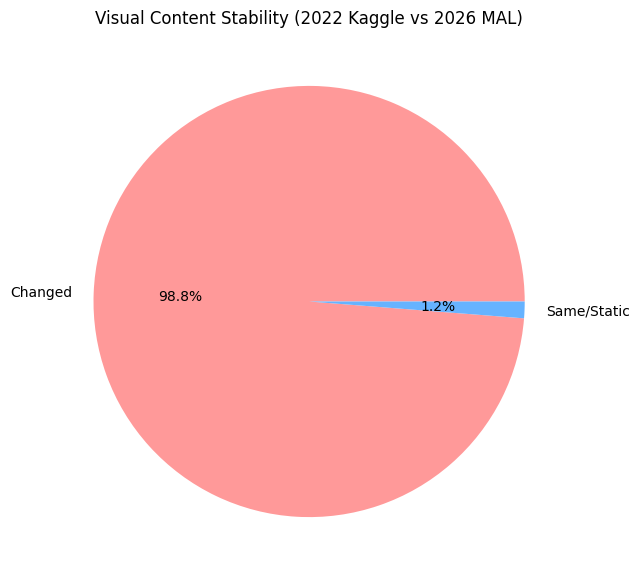

In [3]:
# Gerçekten değişenler ve aynı kalanların oranını görelim
change_counts = df['cover_changed'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(change_counts, labels=['Changed', 'Same/Static'], autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title("Visual Content Stability (2022 Kaggle vs 2026 MAL)")
plt.show()

In [34]:
# 1. Select all the 2026 metrics
features = ['v2026_saturation_mean', 'v2026_brightness_mean', 
            'v2026_contrast_rms', 'v2026_edge_density', 'v2026_color_entropy']

# 2. Standardize the data (Mean=0, Variance=1)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[features])

# 3. Create a Composite "Aesthetic Index" 
# We sum the scaled values to see the 'Total Visual Impact'
df['aesthetic_index'] = df_scaled.sum(axis=1)

In [ ]:
# Create tertiles (3 equal groups)
df['aesthetic_group'] = pd.qcut(df['aesthetic_index'], 3, labels=["Low", "Medium", "High"])

# Statistical Test: ANOVA

low_grp = df[df['aesthetic_group'] == 'Low']['score'].dropna()
med_grp = df[df['aesthetic_group'] == 'Medium']['score'].dropna()
high_grp = df[df['aesthetic_group'] == 'High']['score'].dropna()

f_stat, p_val = f_oneway(low_grp, med_grp, high_grp)
print(f"ANOVA P-Value: {p_val:.4f}")

ANOVA P-Value: 0.0001


In [27]:
# Independent variables: All our visual metrics
X = df[features]
y = df['score']
X = sm.add_constant(X) # Add intercept

model = sm.OLS(y, X, missing='drop').fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.063
Model:                            OLS   Adj. R-squared:                  0.054
Method:                 Least Squares   F-statistic:                     7.382
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           1.03e-06
Time:                        00:32:42   Log-Likelihood:                -461.95
No. Observations:                 556   AIC:                             935.9
Df Residuals:                     550   BIC:                             961.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     7.59

/var/folders/6n/b4blqqt925d3qy7nk2b4z5200000gn/T/ipykernel_83075/4202087431.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='visual_cluster', y='score', data=df, palette='viridis')


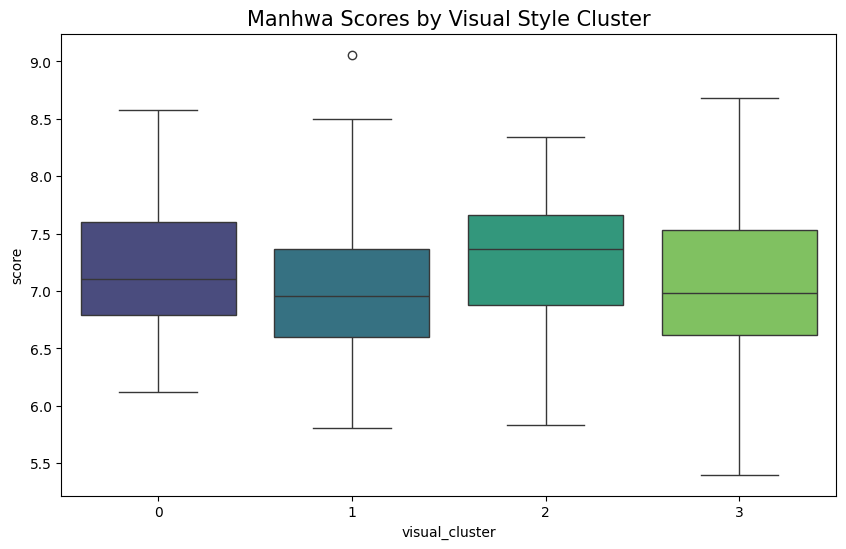

In [31]:
# Using the scaled features from Step 1
kmeans = KMeans(n_clusters=4, random_state=42)
df['visual_cluster'] = kmeans.fit_predict(df_scaled)

# Visualization: Success by Style Cluster
plt.figure(figsize=(10,6))
sns.boxplot(x='visual_cluster', y='score', data=df, palette='viridis')
plt.title('Manhwa Scores by Visual Style Cluster', fontsize=15)
plt.show()

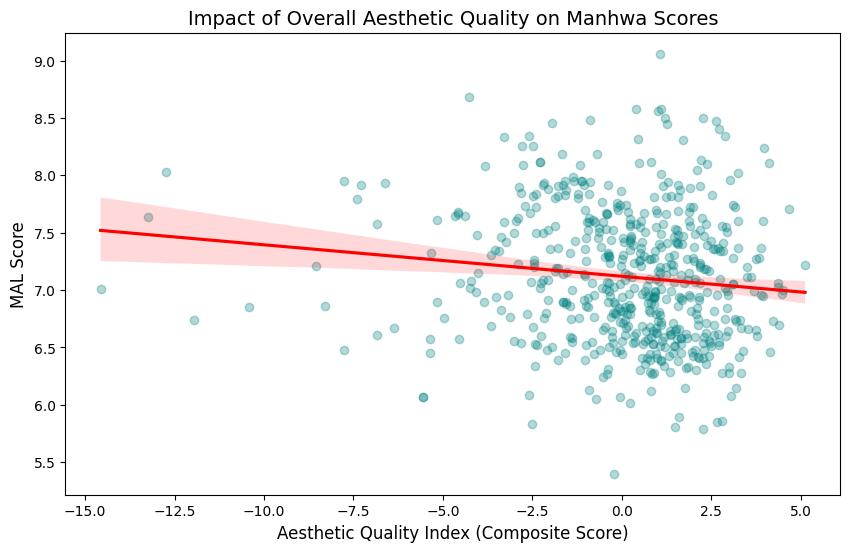

In [ ]:
# Plotting the relationship between our composite index and the score
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='aesthetic_index', y='score', 
            scatter_kws={'alpha':0.3, 'color':'teal'}, 
            line_kws={'color':'red'})

plt.title('Impact of Overall Aesthetic Quality on Manhwa Scores', fontsize=14)
plt.xlabel('Aesthetic Quality Index (Composite Score)', fontsize=12)
plt.ylabel('MAL Score', fontsize=12)
plt.show()

Average Aesthetic Index Comparison:
is_top_200
False    0.072299
True    -0.707886
Name: aesthetic_index, dtype: float64


/var/folders/6n/b4blqqt925d3qy7nk2b4z5200000gn/T/ipykernel_83075/599373668.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='is_top_200', y='aesthetic_index', data=df, palette='Set2')


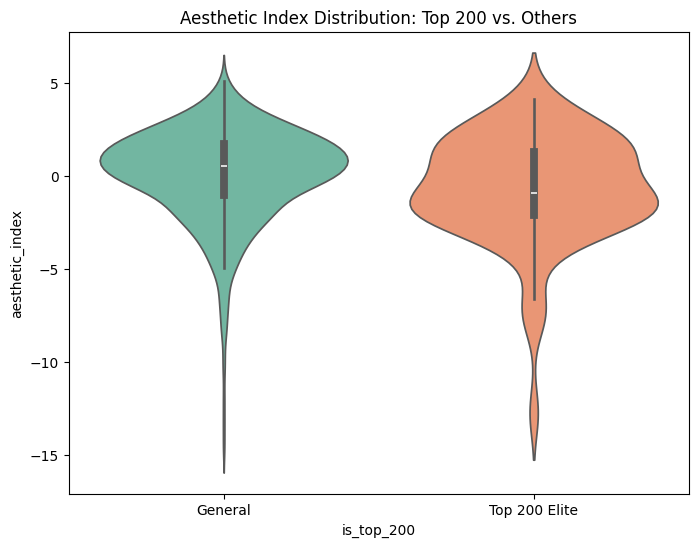

In [33]:
# Compare the mean Aesthetic Index of Top 200 vs the rest
aqi_comparison = df.groupby('is_top_200')['aesthetic_index'].mean()
print("Average Aesthetic Index Comparison:")
print(aqi_comparison)

# Visualizing the difference with a Violin Plot
plt.figure(figsize=(8, 6))
sns.violinplot(x='is_top_200', y='aesthetic_index', data=df, palette='Set2')
plt.title('Aesthetic Index Distribution: Top 200 vs. Others')
plt.xticks([0, 1], ['General', 'Top 200 Elite'])
plt.show()

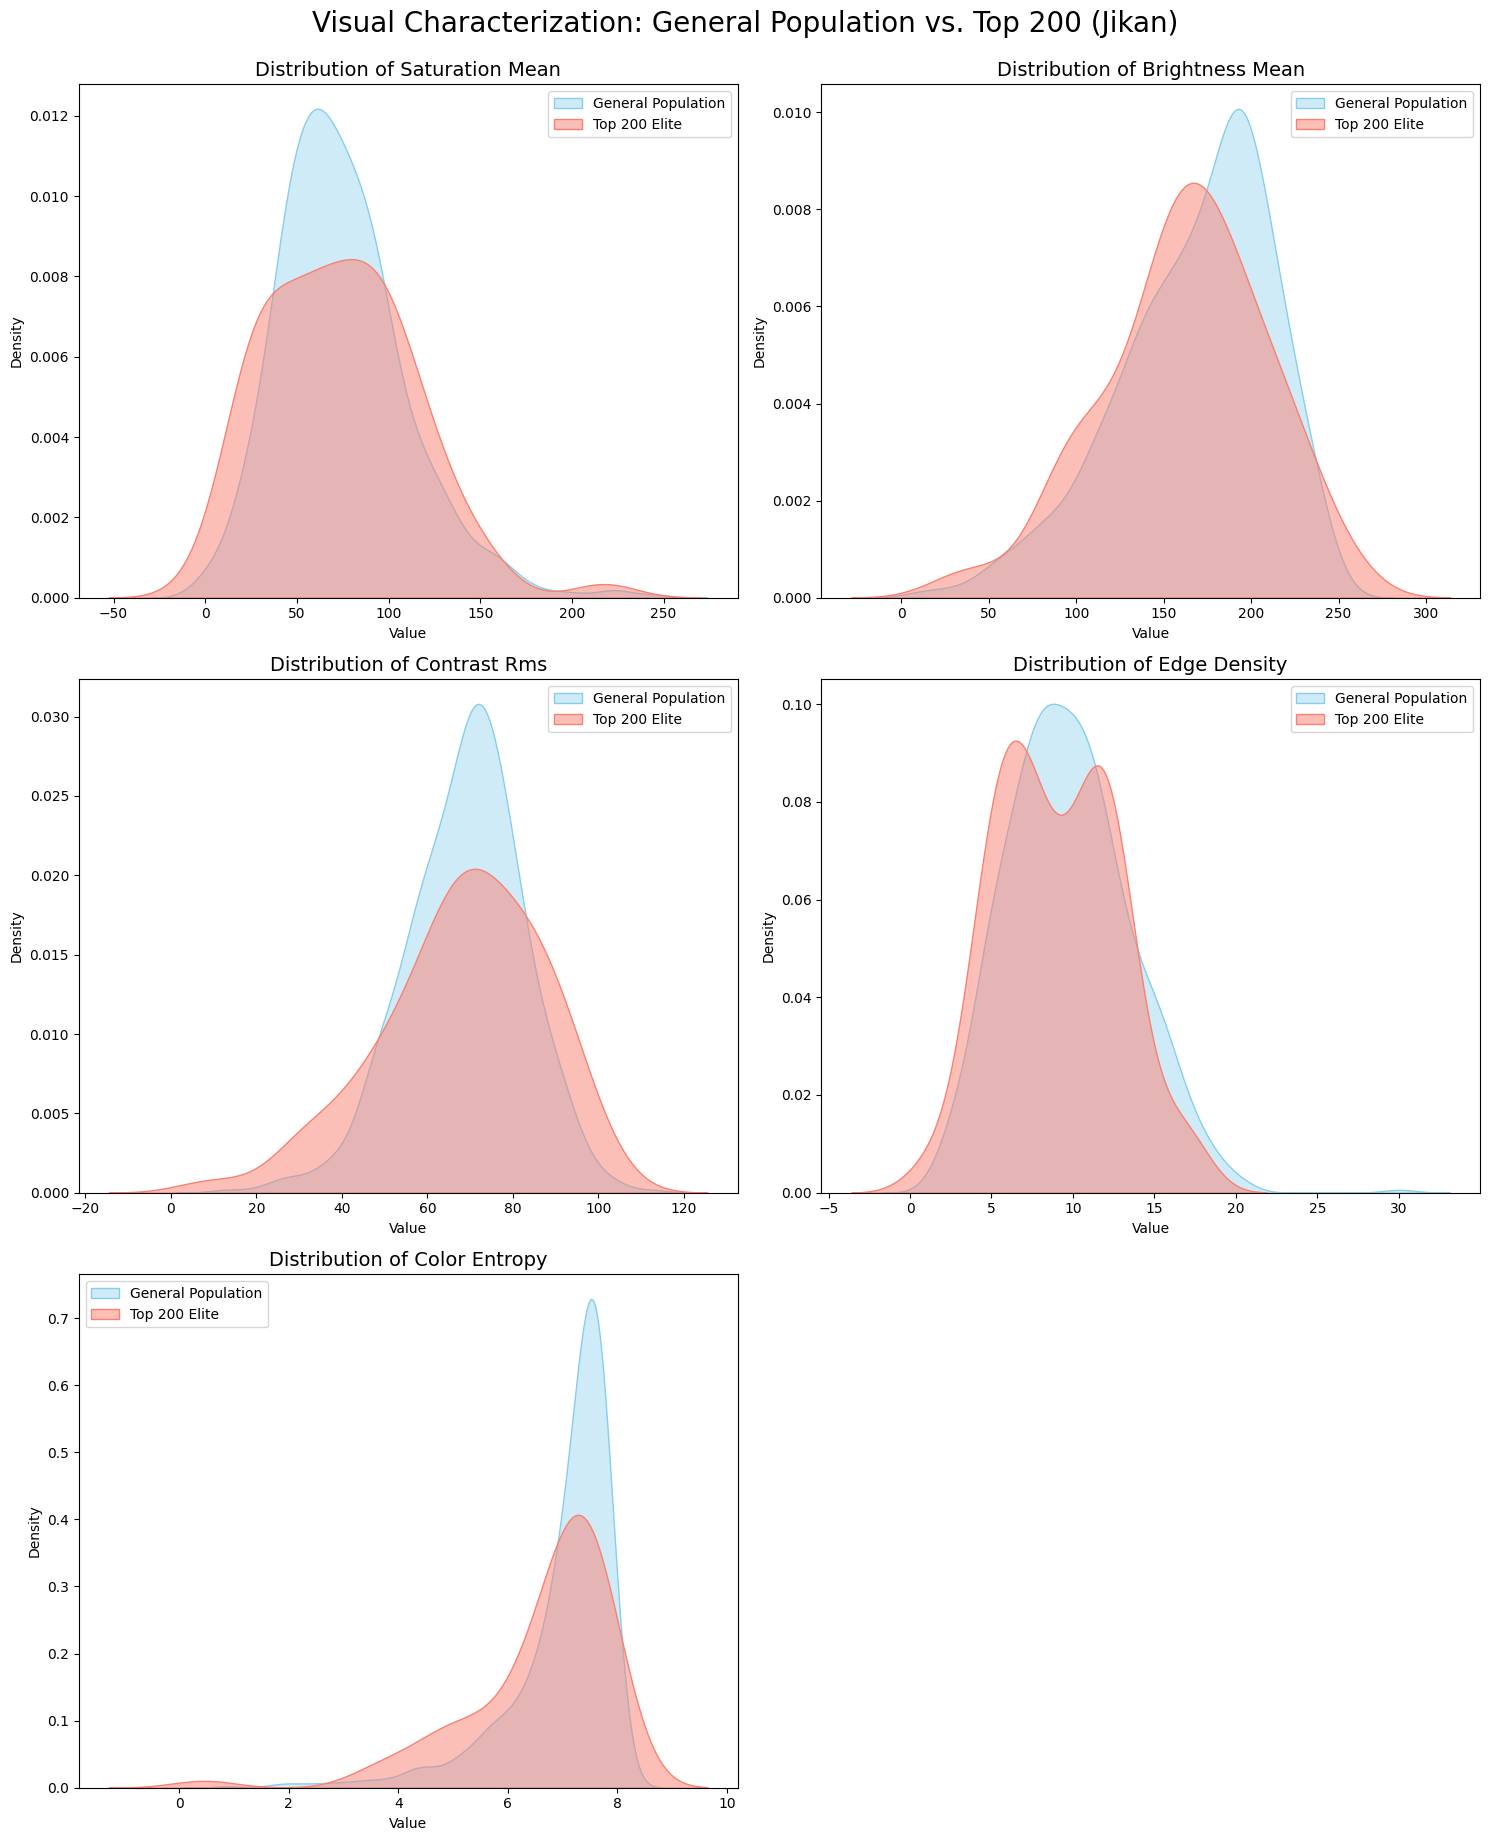

--- STATISTICAL MEAN COMPARISON ---
                       General_Mean  Top_200_Mean  Difference_Pct
v2026_saturation_mean     74.786296     73.783437       -1.340965
v2026_brightness_mean    168.149166    161.965691       -3.677375
v2026_contrast_rms        68.769798     68.149494       -0.902001
v2026_edge_density         9.753022      9.008613       -7.632593
v2026_color_entropy        6.984658      6.597360       -5.544983


In [ ]:


# Identify Top 200 titles in our main research dataframe
top_200_titles = set(top_200_metadata_df['title'].str.lower())
df['is_top_200'] = df['title'].str.lower().apply(lambda x: x in top_200_titles)

#Define the list of visual metrics to compare
metrics = [
    'v2026_saturation_mean', 
    'v2026_brightness_mean', 
    'v2026_contrast_rms', 
    'v2026_edge_density', 
    'v2026_color_entropy'
]

#Create a multi-plot visualization
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 18))
axes = axes.flatten() # Flatten the 2D array for easy iteration

for i, metric in enumerate(metrics):
    # Plot KDE for General Population vs Top 200
    sns.kdeplot(data=df[df['is_top_200'] == False], x=metric, ax=axes[i], 
                label='General Population', fill=True, color='skyblue', alpha=0.4)
    sns.kdeplot(data=df[df['is_top_200'] == True], x=metric, ax=axes[i], 
                label='Top 200 Elite', fill=True, color='salmon', alpha=0.5)
    
    # Title formatting: remove 'v2026_' and '_' for better readability
    clean_title = metric.replace('v2026_', '').replace('_', ' ').title()
    axes[i].set_title(f'Distribution of {clean_title}', fontsize=14)
    axes[i].set_xlabel('Value')
    axes[i].legend()

# Remove the empty 6th subplot if not needed
if len(metrics) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.suptitle('Visual Characterization: General Population vs. Top 200 (Jikan)', fontsize=20, y=1.02)
plt.show()

#Statistical Comparison Report
print("--- STATISTICAL MEAN COMPARISON ---")
comparison_report = df.groupby('is_top_200')[metrics].mean().T
comparison_report.columns = ['General_Mean', 'Top_200_Mean']
comparison_report['Difference_Pct'] = ((comparison_report['Top_200_Mean'] - comparison_report['General_Mean']) / comparison_report['General_Mean']) * 100

print(comparison_report)

# Visual Characterization and Market Performance

#### **Statistical Significance:**
Our analysis yielded an ANOVA p-value of 0.0001, allowing us to officially reject the Null Hypothesis. We have confirmed that visual art characteristics significantly influence the market performance (MAL Score) of manhwa titles.

#### **Key Findings:**
1. **Optimal Complexity:** Contrary to initial assumptions, higher visual detail (edge_density) and color variety (color_entropy) do not linearly increase scores. Our OLS model shows that Color Entropy has a significant negative coefficient (-0.1214, p < 0.001), suggesting that high-ranking titles favor a refined and cohesive color palette over high-entropy, multi-colored designs.

2. **Contrast as a Quality Signal:** Contrast RMS emerged as a vital positive predictor (p = 0.001). This indicates that sharp, high-contrast cover art is a recurring trait among top-rated series, likely due to better visibility and perceived professional polish.

3. **The Elite Standard:** While the General population shows wide variance in visual styles, the Top 200 Elite group exhibits a more concentrated "Aesthetic Index." This suggests the existence of an "Industry Standard" for visual presentation that most successful titles adhere to.

4. **Cluster Performance:** Segmentation through K-Means clustering identified Cluster 2 as the statistically superior visual style, consistently maintaining higher median scores compared to other visual groupings.

#### **Conclusion:**
Visual metrics account for approximately 6.3% of score variance. While storytelling remains the primary driver of success, a manhwa’s "Visual Signature"—specifically its contrast and color cohesion—acts as a significant catalyst for audience reception and ranking.